In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, random
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------
# PATH CONFIG -- auto-detects Kaggle input path so you don't need to
# hardcode the dataset slug. Falls back to local paths if not on Kaggle.
# ---------------------------------------------------------------
def _find_kaggle_data_root():
    # Known exact path for this dataset -- checked first
    explicit_path = Path("/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data")
    if (explicit_path / "w_d_1").exists():
        return explicit_path
    # Fallback auto-detect in case Kaggle mounts it under a different path
    # (e.g. plain /kaggle/input/<slug>/ on some notebook setups)
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return None
    for depth_glob in ("*/w_d_1", "*/*/w_d_1", "*/*/*/w_d_1"):
        hits = list(kaggle_input.glob(depth_glob))
        if hits:
            return hits[0].parent
    return None

_kaggle_root = _find_kaggle_data_root()
if _kaggle_root is not None:
    print(f"Kaggle environment detected -- data root: {_kaggle_root}")
    RAW_DATA_DIRS = {
        "w_d_1": _kaggle_root / "w_d_1",
        "w_d_2": _kaggle_root / "w_d_2",
        "w_d_3": _kaggle_root / "w_d_3",
    }
    PROCESSED_DIR = Path("/kaggle/working/processed")
else:
    # local / non-Kaggle fallback -- edit these if running elsewhere
    RAW_DATA_DIRS = {
        "w_d_1": Path("./w_d_1"),
        "w_d_2": Path("./w_d_2"),
        "w_d_3": Path("./w_d_3"),
    }
    PROCESSED_DIR = Path("./processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def find_processed_file(filename):
    """Locate a processed artifact whether it was produced earlier in THIS
    Kaggle session (/kaggle/working/processed), or comes from a prior
    notebook's saved Output attached as a data source (/kaggle/input/.../processed),
    or sits in the local ./processed fallback."""
    local = PROCESSED_DIR / filename
    if local.exists():
        return local
    if Path("/kaggle/input").exists():
        for p in Path("/kaggle/input").glob(f"*/processed/{filename}"):
            return p
        for p in Path("/kaggle/input").glob(f"*/{filename}"):
            return p
    raise FileNotFoundError(
        f"'{filename}' not found. Either run the prerequisite notebook first in this "
        "same session, or (separate Kaggle notebooks) attach its saved Output as a "
        "data source via Add Data > Your Work > Notebook Output Files."
    )

HOURLY_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall", "snow_depth", "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Kaggle environment detected -- data root: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data


In [2]:
daily = pd.read_parquet(find_processed_file("/kaggle/input/datasets/vishalsonawane77/daily-sample"))
daily["date"] = pd.to_datetime(daily["date"])
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
print("Loaded daily dataset:", daily.shape)

Loaded daily dataset: (206560, 26)


## 2. Indian meteorological seasons & crop-season windows
Winter (Dec–Feb), Summer (Mar–May), Monsoon (Jun–Sep), Post-monsoon (Oct–Nov).  
Kharif ≈ Jun–Oct, Rabi ≈ Oct–Mar (used as the reference windows for PS1).

In [3]:
def to_season(m):
    if m in (12, 1, 2): return "Winter"
    if m in (3, 4, 5): return "Summer"
    if m in (6, 7, 8, 9): return "Monsoon"
    return "Post-Monsoon"

daily["season"] = daily["month"].apply(to_season)

seasonal_avg = daily.groupby("season")[["temp_mean", "precipitation_sum", "humidity_mean"]].mean().round(2)
seasonal_avg = seasonal_avg.reindex(["Winter", "Summer", "Monsoon", "Post-Monsoon"])
seasonal_avg

,temp_mean,precipitation_sum,humidity_mean
season,,,
Winter,18.45,0.72,65.22
Summer,27.35,1.76,53.73
Monsoon,27.55,7.56,76.35
Post-Monsoon,23.43,2.26,68.11


## 3. Monthly climatology (averaged across years and cities)

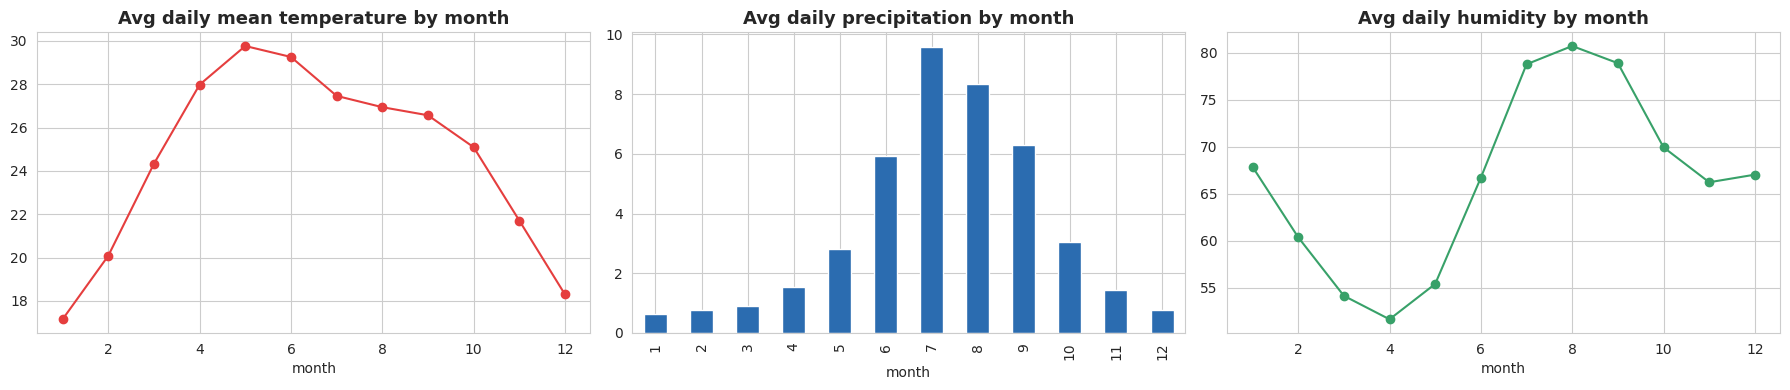

In [4]:
monthly_avg = daily.groupby("month")[["temp_mean", "precipitation_sum", "humidity_mean"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
monthly_avg["temp_mean"].plot(kind="line", marker="o", ax=axes[0], color="#e53e3e")
axes[0].set_title("Avg daily mean temperature by month")
monthly_avg["precipitation_sum"].plot(kind="bar", ax=axes[1], color="#2b6cb0")
axes[1].set_title("Avg daily precipitation by month")
monthly_avg["humidity_mean"].plot(kind="line", marker="o", ax=axes[2], color="#38a169")
axes[2].set_title("Avg daily humidity by month")
plt.tight_layout()
plt.show()

## 4. Monsoon onset detection (feature basis for PS1)
Rule-based proxy: first date each year where 3-day rolling precipitation exceeds a threshold, per city. This is a starting heuristic for feature engineering, not a final agronomic definition -- flag for domain review.

In [5]:
ONSET_THRESHOLD_MM = 30  # 3-day rolling sum threshold, tune with domain expert input

def detect_onset(city_year_df):
    s = city_year_df.set_index("date")["precipitation_sum"].rolling(3).sum()
    hit = s[s >= ONSET_THRESHOLD_MM]
    return hit.index.min() if len(hit) else pd.NaT

onset_records = []
for (city, year), g in daily[daily["month"].between(5, 8)].groupby(["city", "year"]):
    onset_records.append({"city": city, "year": year, "onset_date": detect_onset(g)})

onset_df = pd.DataFrame(onset_records)
onset_df["onset_doy"] = onset_df["onset_date"].dt.dayofyear
onset_df.dropna().groupby("city")["onset_doy"].agg(["mean", "std"]).round(1).sort_values("mean").head(15)

,mean,std
city,,
Kochi,128.6,6.3
Guwahati,128.8,6.3
Mangalam_2,129.1,7.3
Agartala,130.5,7.3
Kishanganj_2,136.4,12.9
Imphal,138.6,12.8
Kulgam,138.6,20.9
Barasat,138.8,16.7
Kaliganj,139.9,16.7


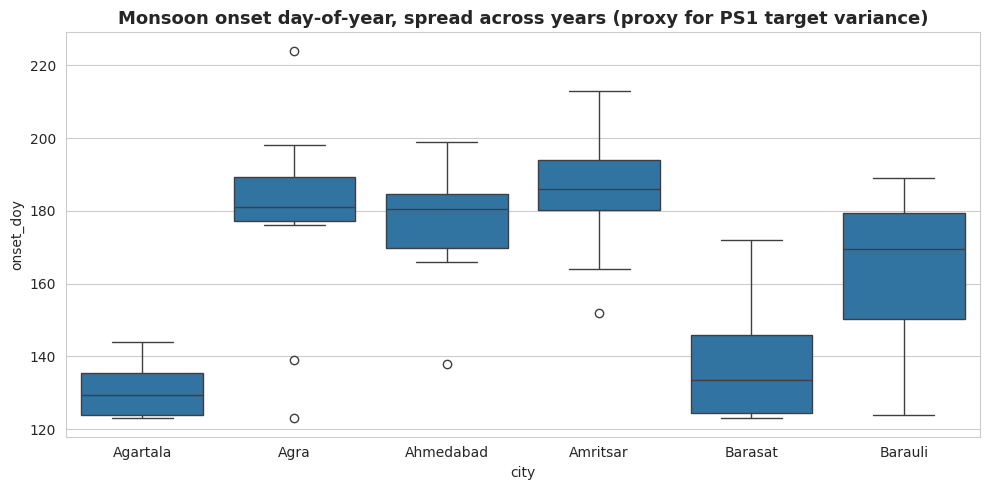

In [6]:
plot_cities = onset_df["city"].dropna().unique()[:6]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=onset_df[onset_df["city"].isin(plot_cities)], x="city", y="onset_doy", ax=ax)
ax.set_title("Monsoon onset day-of-year, spread across years (proxy for PS1 target variance)")
plt.tight_layout()
plt.show()

## 5. Year-over-year trend (warming/drying signal)

In [7]:
from scipy.stats import linregress

trend_rows = []
for city, g in daily.groupby("city"):
    annual = g.groupby("year")["temp_mean"].mean().dropna()
    if len(annual) > 3:
        slope, intercept, r, p, se = linregress(annual.index, annual.values)
        trend_rows.append({"city": city, "temp_trend_C_per_year": slope, "p_value": p})

trend_df = pd.DataFrame(trend_rows).sort_values("temp_trend_C_per_year", ascending=False)
trend_df.round(4)

,city,temp_trend_C_per_year,p_value
32,Leh,0.2641,0.1917
11,Coimbatore,0.0386,0.1123
18,Hindalgi,0.0344,0.0830
28,Kochi,0.0317,0.0837
36,Mangalam_2,0.0216,0.3243
35,Madurai,-0.0142,0.6656
13,Doranala,-0.0213,0.6511
38,Mumbai,-0.0351,0.2790
10,Chennai,-0.0452,0.1717
37,Miryal,-0.0536,0.1289


## 6. Diurnal cycle (needs hourly data — small subset for visualization)

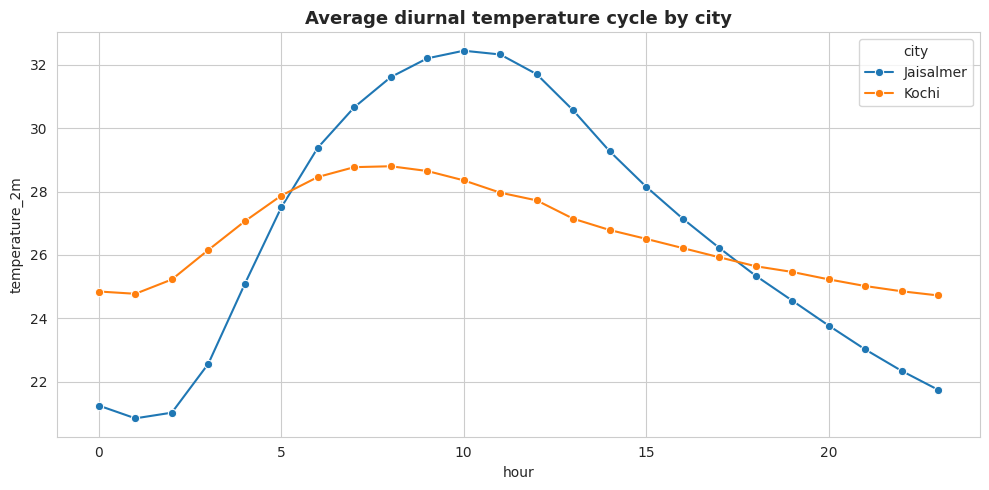

In [9]:
hourly_small = pd.read_parquet(
    PROCESSED_DIR / "/kaggle/input/datasets/vishalsonawane77/hourly-sample-raw",
    columns=["time", "city", "temperature_2m"]
)
hourly_small["time"] = pd.to_datetime(hourly_small["time"])
hourly_small["hour"] = hourly_small["time"].dt.hour

diurnal_cities = [c for c in ["Jaisalmer", "Kochi", "Shimla"] if c in hourly_small["city"].unique()]
diurnal = (hourly_small[hourly_small["city"].isin(diurnal_cities)]
           .groupby(["city", "hour"])["temperature_2m"].mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=diurnal, x="hour", y="temperature_2m", hue="city", marker="o", ax=ax)
ax.set_title("Average diurnal temperature cycle by city")
plt.tight_layout()
plt.show()

## 7. Summary

In [10]:
print("TEMPORAL & SEASONAL ANALYSIS -- SUMMARY")
print("=" * 55)
print(seasonal_avg)
print("\nCities with strongest warming trend (°C/year):")
print(trend_df.head(5)[["city", "temp_trend_C_per_year"]])
print("\nMonsoon onset variability computed for", onset_df["city"].nunique(), "cities.")

TEMPORAL & SEASONAL ANALYSIS -- SUMMARY
              temp_mean  precipitation_sum  humidity_mean
season                                                   
Winter            18.45               0.72          65.22
Summer            27.35               1.76          53.73
Monsoon           27.55               7.56          76.35
Post-Monsoon      23.43               2.26          68.11

Cities with strongest warming trend (°C/year):
          city  temp_trend_C_per_year
32         Leh               0.264097
11  Coimbatore               0.038644
18    Hindalgi               0.034415
28       Kochi               0.031674
36  Mangalam_2               0.021616

Monsoon onset variability computed for 40 cities.
